# OSM New Editor and First Changeset Discussion Analysis (2026)

This notebook uses the OSMCha API with the provided AOI filter and token to:
- fetch first changesets inside the selected  AOI (As the API calls  may be time consuming, limit the number of changsets in the AOI to about 100, which may take about 3-5 minutes)
- inspect whether those first changesets received discussion comments
- plot the delay between changeset creation and first discussion comment
- plot number of changesets checked (checked:true/false), number of changesets reviewed bad (harmful:true), reviewed good (harmful:false)
- Review user activity for 30 days  after first changeset was reviewed and present the same.

> Note: The AOI filter uses the OSMCha AOI endpoint. The OSMCha token is loaded from the environment variable `OSMCHA_TOKEN` so it is not stored in the notebook file. Discussion timestamps are retrieved from the OpenStreetMap changeset API.


In [1]:
import os
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta

plt.style.use("seaborn-v0_8")

OSMCHA_TOKEN = os.environ.get("OSMCHA_TOKEN")
if not OSMCHA_TOKEN:
    raise EnvironmentError("OSMCHA_TOKEN environment variable is required")

OSMCHA_API_URL = "https://osmcha.org/api/v1"
AOI_ID = "05ef4393-c799-4d3e-aec1-25c317d0c79d"
OSM_API_URL = "https://api.openstreetmap.org/api/0.6"

session = requests.Session()
session.headers.update({
    "User-Agent": "copilot-osm-analysis/1.0",
    "Authorization": f"Token {OSMCHA_TOKEN}",
})

## Environment setup

This notebook reads the OSMCha token from the environment variable `OSMCHA_TOKEN` so that the secret is not committed to the repository.

To run this notebook in your shell, set the token first:
```bash
export OSMCHA_TOKEN=your_token_here
```

A sample `.env.example` file is included in the repository for reference.


In [2]:
def fetch_osmcha_aoi_changesets(aoi_id: str, page_size: int = 100) -> pd.DataFrame:
    url = f"{OSMCHA_API_URL}/aoi/{aoi_id}/changesets/"
    features = []
    page = 1
    while True:
        params = {"page": page, "page_size": page_size}
        response = session.get(url, params=params, timeout=120)
        response.raise_for_status()
        data = response.json()
        page_features = data.get("features", [])
        if not page_features:
            break
        features.extend(page_features)
        if not data.get("next"):
            break
        page += 1
        time.sleep(0.5)
    if not features:
        return pd.DataFrame()
    return pd.json_normalize(features, sep="_")

def fetch_osm_changeset_with_discussion(changeset_id: int) -> dict:
    url = f"{OSM_API_URL}/changeset/{changeset_id}.json"
    response = requests.get(url, params={"include_discussion": "true"}, headers={"User-Agent": "copilot-osm-analysis/1.0"}, timeout=120)
    response.raise_for_status()
    return response.json()

def get_first_discussion_datetime(changeset_json: dict):
    comments = changeset_json.get("changeset", {}).get("comments", [])
    if not comments:
        return None
    dates = [pd.to_datetime(c["date"]) for c in comments if c.get("date")]
    return min(dates) if dates else None

def fetch_osm_user_changesets_in_period(user_id: int, start: datetime = None, end: datetime = None):
    """Fetch user changesets from the OSM API /api/0.6/changesets in the given time range."""
    if user_id is None:
        raise ValueError("user_id is required to fetch user changesets")
    if start is None or end is None:
        raise ValueError("start and end datetime are required")
    params = {
        "time": f"{start.strftime('%Y-%m-%dT%H:%M:%SZ')},{end.strftime('%Y-%m-%dT%H:%M:%SZ')}",
        "user": int(user_id),
    }
    response = requests.get(f"{OSM_API_URL}/changesets", params=params, headers={"User-Agent": "copilot-osm-analysis/1.0"}, timeout=120)
    response.raise_for_status()
    root = ET.fromstring(response.content)
    return [int(el.attrib['id']) for el in root.findall('changeset')]

def count_edits_after_discussion(row, window_days: int = 30):
    if pd.isna(row.get("first_comment_datetime")) or row["first_comment_datetime"] is None:
        return None
    user_id = row.get("properties_uid") if "properties_uid" in row else None
    if pd.isna(user_id) or user_id is None:
        return None
    start = row["first_comment_datetime"] + pd.Timedelta(seconds=1)
    end = start + pd.Timedelta(days=window_days)
    try:
        edits = fetch_osm_user_changesets_in_period(user_id=int(user_id), start=start, end=end)
        return len(edits)
    except Exception as exc:
        print(f"Failed to fetch edits for user {user_id}: {exc}")
        return None

In [3]:
# Step 1: Fetch changesets from the provided OSMCha AOI filter
osmcha_changesets = fetch_osmcha_aoi_changesets(AOI_ID, page_size=100)
print(f"Fetched {len(osmcha_changesets)} Osmcha changeset features for AOI {AOI_ID}")
osmcha_changesets.head()


Fetched 145 Osmcha changeset features for AOI 05ef4393-c799-4d3e-aec1-25c317d0c79d


,id,type,geometry_type,geometry_coordinates,properties_check_user,properties_reasons,properties_tags,properties_features,properties_user,properties_uid,...,properties_tag_changes_payment:credit_cards,properties_tag_changes_opening_hours,properties_tag_changes_junction,properties_tag_changes_type,properties_tag_changes_name:te,properties_tag_changes_short_name:te,properties_tag_changes_loc_name:name:loc,properties_tag_changes_informal,properties_tag_changes_healthcare,properties_tag_changes_healthcare:speciality
0,176768410,Feature,Polygon,"[[[80.1112946, 16.166866], [80.1112946, 16.166...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}, {'id': 86, ...",[],[],Pavan Komirisetty,23668422,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,176891017,Feature,Polygon,"[[[80.8289802, 16.0351363], [80.8402645, 16.03...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]","[{'id': 10, 'name': 'Unresolved'}]",[],Mohana Dokku,23677212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,176892861,Feature,Polygon,"[[[80.1910467, 15.8971858], [80.200224, 15.897...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}, {'id': 517,...","[{'id': 6, 'name': 'Severity: Low'}]",[],Amarnath07,23677287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,176894070,Feature,Polygon,"[[[80.0167603, 15.7050239], [80.0815638, 15.70...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],KrisVar,23677295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,176894166,Feature,Polygon,"[[[79.5521225, 13.6016232], [79.5791831, 13.60...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],Balaraju Bollini,23677297,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Tag columns detected: ['properties_tags', 'properties_metadata_hashtags', 'properties_metadata_resolved:outdated_tags:incomplete_tags']
   id            name  count
2   6   Severity: Low     75
4   9        Resolved     72
5  10      Unresolved     17
3   7  Severity: High     10
1   2   Unintentional      1


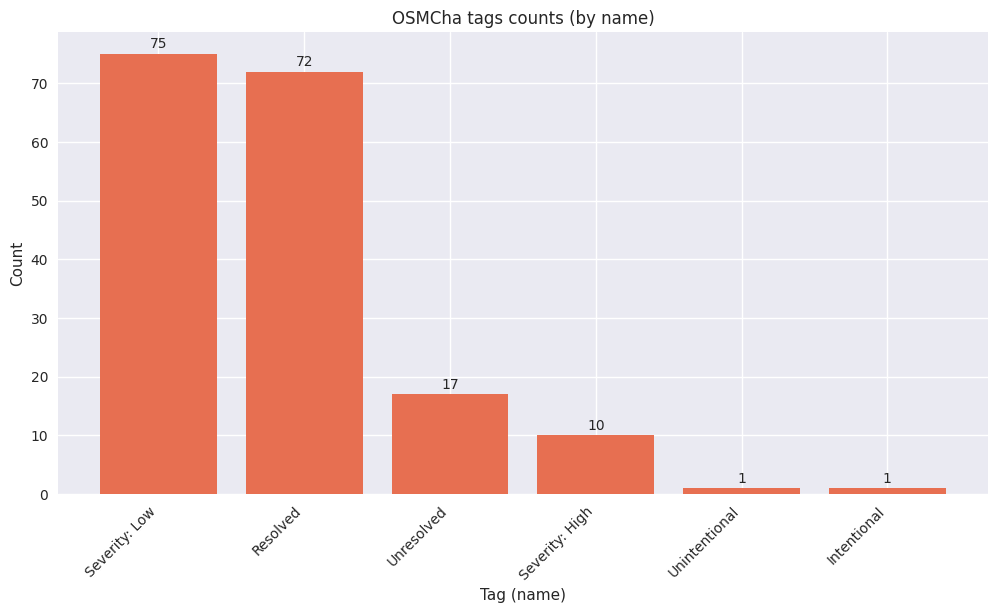

In [4]:
# Step 2: Parse OSMCha `tags` metadata and plot counts by tag id (displaying names)
def extract_tags_map(tags_field):
    """
    `tags_field` expected to be a list of dicts like [{'id':6,'name':'Severity: Low'}, ...]
    Return dict id->name
    """
    if isinstance(tags_field, list):
        try:
            return {int(t.get("id")): t.get("name") for t in tags_field if t.get("id") is not None}
        except Exception:
            return {}
    return {}

# Detect columns that may contain tags (common normalized column names)
tag_cols = [c for c in osmcha_changesets.columns if c.endswith("tags") or c.endswith("_tags") or "_tags_" in c or c.lower().endswith("tags")]
print("Tag columns detected:", tag_cols)

# Prefer a direct 'properties_metadata_tags' or first matching column
tags_column = None
for candidate in ["properties_metadata_tags", "properties_tags"] + tag_cols:
    if candidate in osmcha_changesets.columns:
        tags_column = candidate
        break

if tags_column:
    osmcha_changesets["tags_map"] = osmcha_changesets[tags_column].apply(extract_tags_map)
else:
    # As a best-effort, try to locate a nested metadata field inside 'properties_metadata' if present
    if "properties_metadata" in osmcha_changesets.columns:
        osmcha_changesets["tags_map"] = osmcha_changesets["properties_metadata"].apply(lambda m: extract_tags_map(m.get("tags") if isinstance(m, dict) else None) if pd.notna(m) else {})
    else:
        osmcha_changesets["tags_map"] = [{} for _ in range(len(osmcha_changesets))]

# Flatten tags into a DataFrame of (id, name) rows
rows = []
for _, row in osmcha_changesets.iterrows():
    tags_map = row.get("tags_map") or {}
    if isinstance(tags_map, dict):
        for tid, tname in tags_map.items():
            rows.append({"id": int(tid), "name": tname})

tags_df = pd.DataFrame(rows)
if tags_df.empty:
    print("No tags found in dataset.")
else:
    tag_counts = tags_df.groupby(["id", "name"]).size().reset_index(name="count").sort_values("count", ascending=False)
    print(tag_counts.head())
    # Plot bar chart of counts with name labels
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(tag_counts["name"].astype(str), tag_counts["count"], color="#e76f51")
    ax.set_title("OSMCha tags counts (by name)")
    ax.set_xlabel("Tag (name)")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    for i, v in enumerate(tag_counts["count"]):
        ax.text(i, v + 0.5, str(v), ha="center", va="bottom")
    plt.show()

In [5]:
osmcha_changesets["properties_date"] = pd.to_datetime(osmcha_changesets["properties_date"])
osmcha_changesets["first_month"] = osmcha_changesets["properties_date"].dt.to_period("M").astype(str)
osmcha_changesets["discussion_status"] = osmcha_changesets["properties_comments_count"].apply(lambda x: "has_comments" if x > 0 else "no_comments")

monthly_summary = osmcha_changesets.groupby("first_month").size().reset_index(name="first_changeset_editors")
monthly_summary


/tmp/ipykernel_31962/1585405128.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  osmcha_changesets["first_month"] = osmcha_changesets["properties_date"].dt.to_period("M").astype(str)


,first_month,first_changeset_editors
0,2026-01,27
1,2026-02,60
2,2026-03,35
3,2026-04,23


In [6]:
# Step 3: Inspect discussion timestamps for first changesets with comments
commented_first_cs = osmcha_changesets[osmcha_changesets["properties_comments_count"] > 0].copy()
print(f"Attempting to inspect discussion for {len(commented_first_cs)} first changesets")

first_comment_datetimes = []
for changeset_id in commented_first_cs["id"]:
    try:
        cs_json = fetch_osm_changeset_with_discussion(changeset_id)
        first_comment_datetimes.append(get_first_discussion_datetime(cs_json))
    except Exception as exc:
        print(f"Failed to fetch discussion for changeset {changeset_id}: {exc}")
        first_comment_datetimes.append(None)
    time.sleep(1)

commented_first_cs["first_comment_datetime"] = pd.to_datetime(first_comment_datetimes, errors="coerce", utc=True)
commented_first_cs["properties_date"] = pd.to_datetime(commented_first_cs["properties_date"], errors="coerce", utc=True)
commented_first_cs["discussion_delay_hours"] = (commented_first_cs["first_comment_datetime"] - commented_first_cs["properties_date"]).dt.total_seconds() / 3600.0
commented_first_cs.head()

Attempting to inspect discussion for 134 first changesets


,id,type,geometry_type,geometry_coordinates,properties_check_user,properties_reasons,properties_tags,properties_features,properties_user,properties_uid,...,properties_tag_changes_short_name:te,properties_tag_changes_loc_name:name:loc,properties_tag_changes_informal,properties_tag_changes_healthcare,properties_tag_changes_healthcare:speciality,tags_map,first_month,discussion_status,first_comment_datetime,discussion_delay_hours
1,176891017,Feature,Polygon,"[[[80.8289802, 16.0351363], [80.8402645, 16.03...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]","[{'id': 10, 'name': 'Unresolved'}]",[],Mohana Dokku,23677212,...,NaN,NaN,NaN,NaN,NaN,{10: 'Unresolved'},2026-01,has_comments,2026-01-07 02:03:34+00:00,18.167500
2,176892861,Feature,Polygon,"[[[80.1910467, 15.8971858], [80.200224, 15.897...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}, {'id': 517,...","[{'id': 6, 'name': 'Severity: Low'}]",[],Amarnath07,23677287,...,NaN,NaN,NaN,NaN,NaN,{6: 'Severity: Low'},2026-01,has_comments,2026-01-07 01:58:40+00:00,17.102222
3,176894070,Feature,Polygon,"[[[80.0167603, 15.7050239], [80.0815638, 15.70...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],KrisVar,23677295,...,NaN,NaN,NaN,NaN,NaN,{},2026-01,has_comments,2026-01-07 01:48:56+00:00,16.327222
4,176894166,Feature,Polygon,"[[[79.5521225, 13.6016232], [79.5791831, 13.60...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],Balaraju Bollini,23677297,...,NaN,NaN,NaN,NaN,NaN,{},2026-01,has_comments,2026-01-07 01:47:10+00:00,16.246944
5,176894301,Feature,Polygon,"[[[79.7594684, 13.3333491], [79.8837396, 13.33...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}, {'id': 521,...","[{'id': 6, 'name': 'Severity: Low'}, {'id': 9,...",[],Gunadeep,23677302,...,NaN,NaN,NaN,NaN,NaN,"{6: 'Severity: Low', 9: 'Resolved'}",2026-01,has_comments,2026-01-07 01:45:14+00:00,16.142222


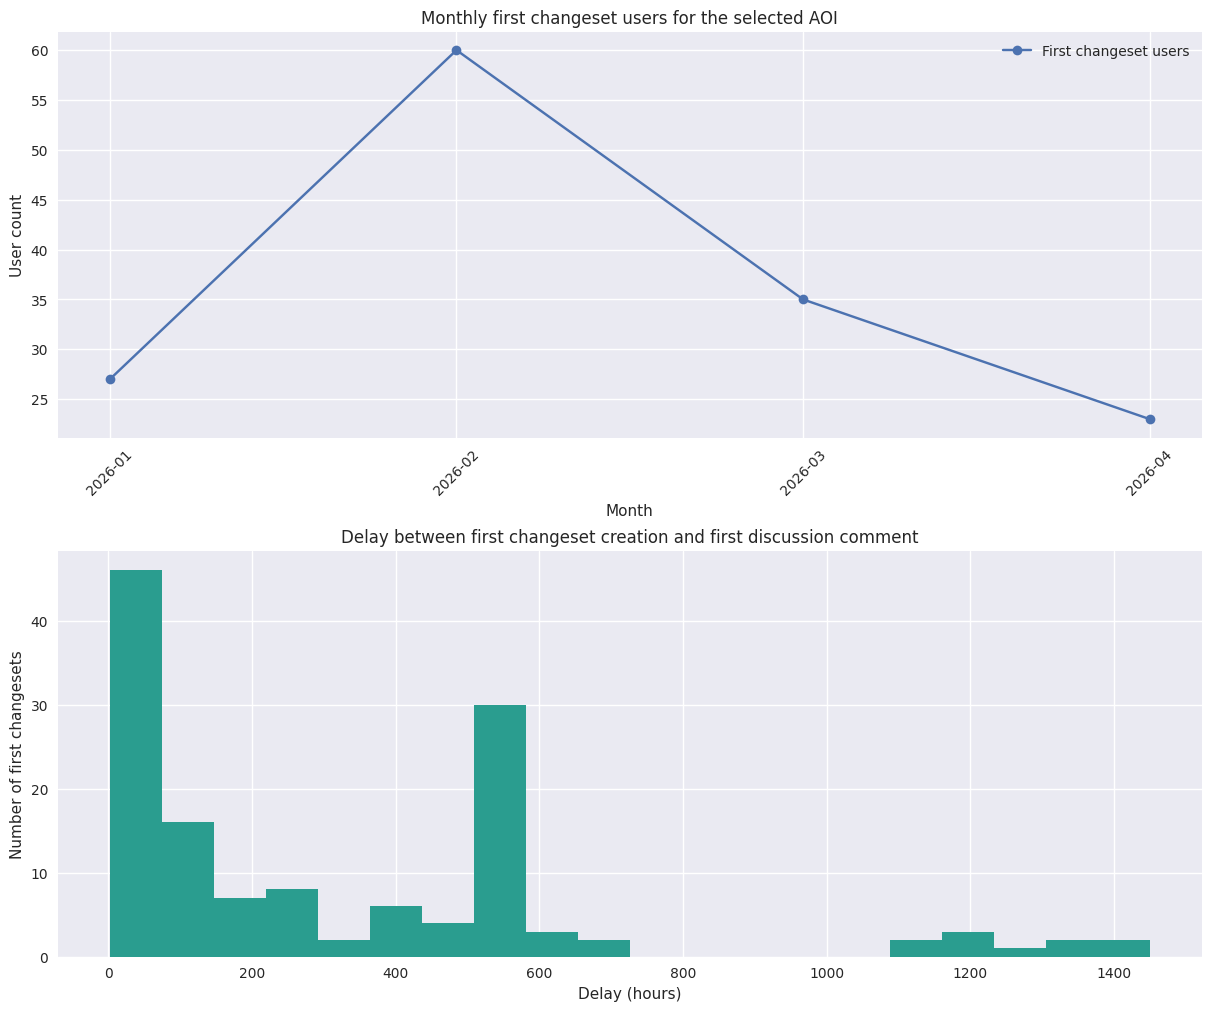

In [7]:
# Step 4: Plot monthly counts and discussion delay distribution
fig, axes = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)

axes[0].plot(monthly_summary["first_month"], monthly_summary["first_changeset_editors"], marker="o", label="First changeset users")
axes[0].set_title("Monthly first changeset users for the selected AOI")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("User count")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(commented_first_cs["discussion_delay_hours"].dropna(), bins=20, color="#2a9d8f")
axes[1].set_title("Delay between first changeset creation and first discussion comment")
axes[1].set_xlabel("Delay (hours)")
axes[1].set_ylabel("Number of first changesets")

plt.show()


Checked columns: ['properties_checked']
Harmful columns: ['properties_harmful']
Using checked column: properties_checked
Using harmful column: properties_harmful

Checked AND Harmful combinations:
   properties_checked  properties_harmful  count                        label
0                True               False     45  Checked=True, Harmful=False
1                True                True     92   Checked=True, Harmful=True


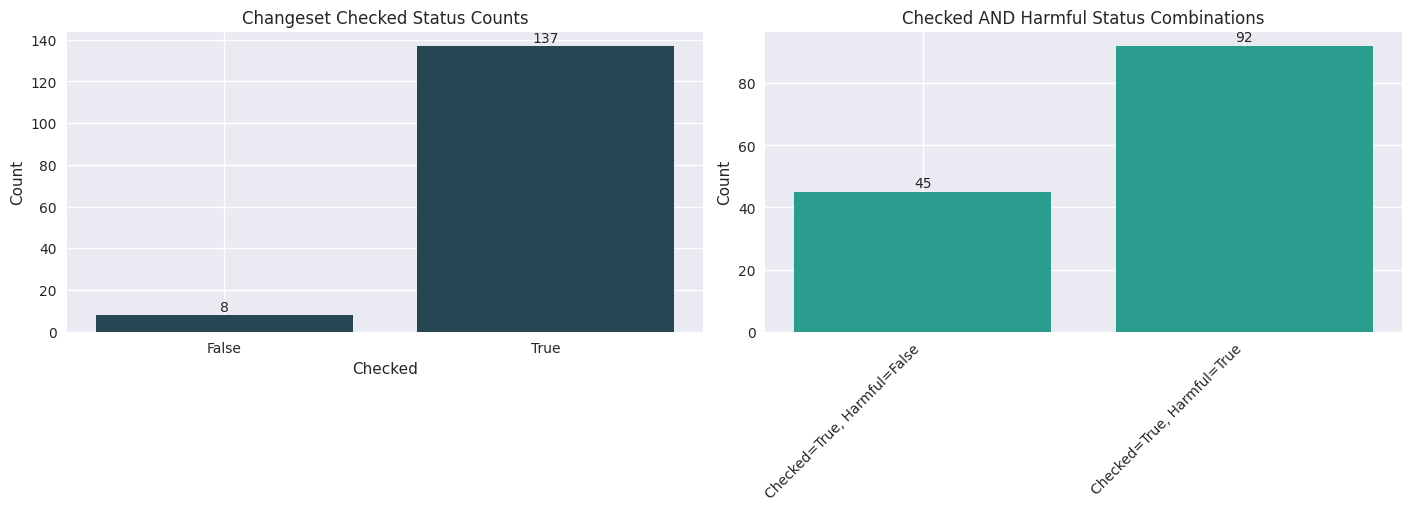

In [8]:
# Step 5: Plot checked and harmful status distributions
# First, check what columns contain checked/harmful data
checked_cols = [c for c in osmcha_changesets.columns if 'checked' in c.lower()]
harmful_cols = [c for c in osmcha_changesets.columns if 'harmful' in c.lower()]

print("Checked columns:", checked_cols)
print("Harmful columns:", harmful_cols)

# Use the normalized column names if available
checked_col = "properties_checked" if "properties_checked" in osmcha_changesets.columns else (checked_cols[0] if checked_cols else None)
harmful_col = "properties_harmful" if "properties_harmful" in osmcha_changesets.columns else (harmful_cols[0] if harmful_cols else None)

print(f"Using checked column: {checked_col}")
print(f"Using harmful column: {harmful_col}")

# Create subplots for checked and harmful status
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Plot 1: Checked status counts
if checked_col and checked_col in osmcha_changesets.columns:
    checked_counts = osmcha_changesets[checked_col].value_counts().sort_index()
    axes[0].bar(checked_counts.index.astype(str), checked_counts.values, color="#264653")
    axes[0].set_title("Changeset Checked Status Counts")
    axes[0].set_xlabel("Checked")
    axes[0].set_ylabel("Count")
    for i, v in enumerate(checked_counts.values):
        axes[0].text(i, v + 0.5, str(v), ha="center", va="bottom")
else:
    axes[0].text(0.5, 0.5, "Checked column not found", ha="center", va="center", transform=axes[0].transAxes)

# Plot 2: Checked AND Harmful combinations
if checked_col and harmful_col and checked_col in osmcha_changesets.columns and harmful_col in osmcha_changesets.columns:
    combo_counts = osmcha_changesets.groupby([checked_col, harmful_col]).size().reset_index(name="count")
    combo_counts["label"] = "Checked=" + combo_counts[checked_col].astype(str) + ", Harmful=" + combo_counts[harmful_col].astype(str)
    
    axes[1].bar(range(len(combo_counts)), combo_counts["count"], color="#2a9d8f")
    axes[1].set_xticks(range(len(combo_counts)))
    axes[1].set_xticklabels(combo_counts["label"], rotation=45, ha="right")
    axes[1].set_title("Checked AND Harmful Status Combinations")
    axes[1].set_ylabel("Count")
    for i, v in enumerate(combo_counts["count"]):
        axes[1].text(i, v + 0.5, str(v), ha="center", va="bottom")
    
    print("\nChecked AND Harmful combinations:")
    print(combo_counts)
else:
    axes[1].text(0.5, 0.5, "Checked or Harmful column not found", ha="center", va="center", transform=axes[1].transAxes)

plt.show()


Counting edits for 134 discussed first changeset users with review at least 30 days ago
User Mohana Dokku: 3 edits in 30 days
User Amarnath07: 5 edits in 30 days
User KrisVar: 6 edits in 30 days
User Balaraju Bollini: 4 edits in 30 days
User Gunadeep: 3 edits in 30 days
User Tharaka13: 19 edits in 30 days
User spectre007: 0 edits in 30 days
User Navyendra: 0 edits in 30 days
User Bhaskar_G: 0 edits in 30 days
User HARSHAVARDHAN514000: 100 edits in 30 days
User Roshi03: 0 edits in 30 days
User trajectory: 0 edits in 30 days
User ar_Mahalakshmi *: 0 edits in 30 days
User Mana ooru mall: 0 edits in 30 days
User Basha kandukuru: 0 edits in 30 days
User Silver Oaks OakHills: 0 edits in 30 days
User sathibabu_srm: 0 edits in 30 days
User GSaikrishna12: 0 edits in 30 days
User Proudcrab: 0 edits in 30 days
User Jangam Sanjay: 0 edits in 30 days
User Harsha Chitti: 0 edits in 30 days
User Sunilms: 0 edits in 30 days
User Luckymall: 0 edits in 30 days
User Kedarnath reddy Malreddy: 0 edits in 3

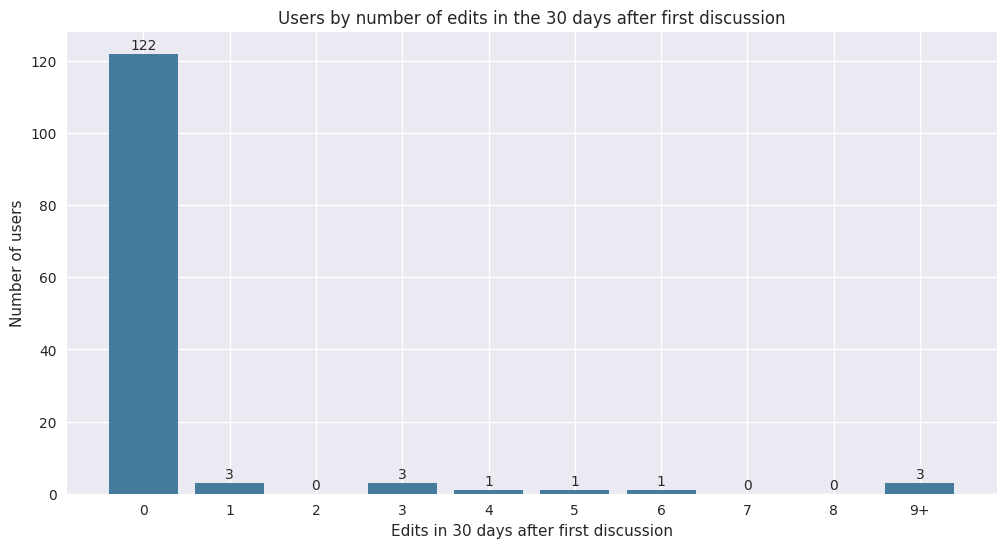

,edit_count_bin,user_count
0,0,122
1,1,3
2,2,0
3,3,3
4,4,1
5,5,1
6,6,1
7,7,0
8,8,0
9,9+,3


In [9]:
# Step 6: Count user edit activity in the 30 days after the first discussion comment
commented_first_cs = commented_first_cs.copy()

def categorize_edit_counts(count):
    if count is None:
        return None
    return str(count) if count < 9 else "9+"

# Only count users we could resolve and whose first discussion happened at least 30 days ago
discussion_users = commented_first_cs[commented_first_cs["first_comment_datetime"].notna()].copy()
cutoff_date = pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=30)
discussion_users = discussion_users[discussion_users["first_comment_datetime"] <= cutoff_date].copy()
print(f"Counting edits for {len(discussion_users)} discussed first changeset users with review at least 30 days ago")

edit_counts = []
for idx, row in discussion_users.iterrows():
    user_display = row.get("properties_user")
    user_id = row.get("properties_uid") if "properties_uid" in row else None
    count = count_edits_after_discussion(row, window_days=30)
    edit_counts.append(count)
    print(f"User {user_display or user_id}: {count} edits in 30 days")
    time.sleep(1)

discussion_users["edits_30d_after_first_discussion"] = edit_counts
discussion_users["edit_count_bin"] = discussion_users["edits_30d_after_first_discussion"].apply(categorize_edit_counts)

edit_activity_by_bin = discussion_users[discussion_users["edit_count_bin"].notna()].groupby("edit_count_bin").size().reindex([str(i) for i in range(0, 9)] + ["9+"], fill_value=0).reset_index(name="user_count")

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(edit_activity_by_bin["edit_count_bin"], edit_activity_by_bin["user_count"], color="#457b9d")
ax.set_title("Users by number of edits in the 30 days after first discussion")
ax.set_xlabel("Edits in 30 days after first discussion")
ax.set_ylabel("Number of users")
for i, count in enumerate(edit_activity_by_bin["user_count"]):
    ax.text(i, count + 0.5, str(count), ha="center", va="bottom")
plt.show()

edit_activity_by_bin

## Limitations and notes
- The OSMCha AOI endpoint is used with the provided AOI ID and token.
- The token is loaded from the environment variable `OSMCHA_TOKEN` so it does not get saved in the notebook file.
- Discussion timestamps are retrieved from the OpenStreetMap changeset API using `include_discussion=true`.
- If the AOI contains many changesets, the API may paginate results; this notebook handles pagination for the OSMCha AOI changeset endpoint.
- OSM API discussion details may still require rate-limiting or caching for larger datasets.
